**Challenge 1**
Text mining

1.  `Setup URL`

In [13]:
url = 'https://en.wikipedia.org/wiki/Data_science'

headers = {
    'User-Agent': 'BelajarDataScience/1.0 ()' 
}

2. `Ambil Data`

In [14]:
import requests

response = requests.get(url, headers=headers).content.decode('utf-8')
print(response[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feat

3. `Rubah data`

In [15]:
from bs4 import BeautifulSoup

#  mengurai konten HTMl
soup = BeautifulSoup(response, "lxml")

# mengambil hanya artikel utama
# wikipedia menggunakan class 'mw-parser-output' pada konten artikel utamanya
konten = soup.find('div', class_='mw-parser-output') 

def membersihkan_konten_wiki(node_konten):
    """Menghapus elemen non-artikel umum"""
    # Strip jump links, navboxes, reference lists/superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
    for selector in selectors:
        for el in node_konten.select(selector):
            el.decompose()

if konten:
    # membersihkan konten agar mendapat tulisan saja
    membersihkan_konten_wiki(konten)
    teks = konten.get_text(separator=' ', strip=True)
    print(teks[:1000])
else:
    print("Tidak dapat menemukan konten utama")
    teks = konten.get_text(separator=' ', strip=True)
    print(teks[:1000])

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession. Data science is "a concept to unify statistics , data analysis , informatics , and their related methods " to "understand and analyze actual phenomena " with data . It uses techniq

4. `Mengambil Insight`

In [19]:
import nlp_rake
extractor = nlp_rake.Rake(max_words=2, min_freq=3, min_chars=5)
res = extractor.apply(teks)
res

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9047619047619047),
 ('computer science', 3.9047619047619047),
 ('^ davenport', 3.8),
 ('information science', 3.738095238095238),
 ('data analysis', 3.7272727272727275),
 ('cloud computing', 3.666666666666667),
 ('science', 1.9047619047619047),
 ('analysis', 1.7272727272727273),
 ('computing', 1.6666666666666667),
 ('sciences', 1.4),
 ('statistics', 1.3),
 ('processing', 1.25),
 ('education', 1.25),
 ('field', 1.2),
 ('thomas', 1.2),
 ('study', 1.0),
 ('techniques', 1.0),
 ('report', 1.0),
 ('process', 1.0),
 ('david', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

4. `Visualisasi Hasil`

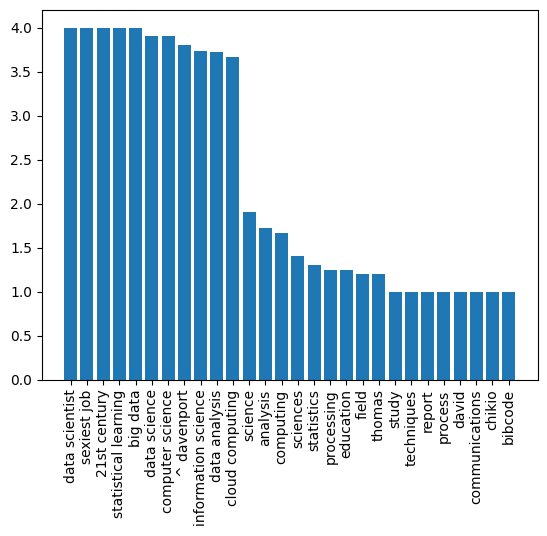

In [20]:
import matplotlib.pyplot as plt

def plot(pair_list):
    k, v =zip(*pair_list)
    plt.bar(range(len(k)),v)
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res)

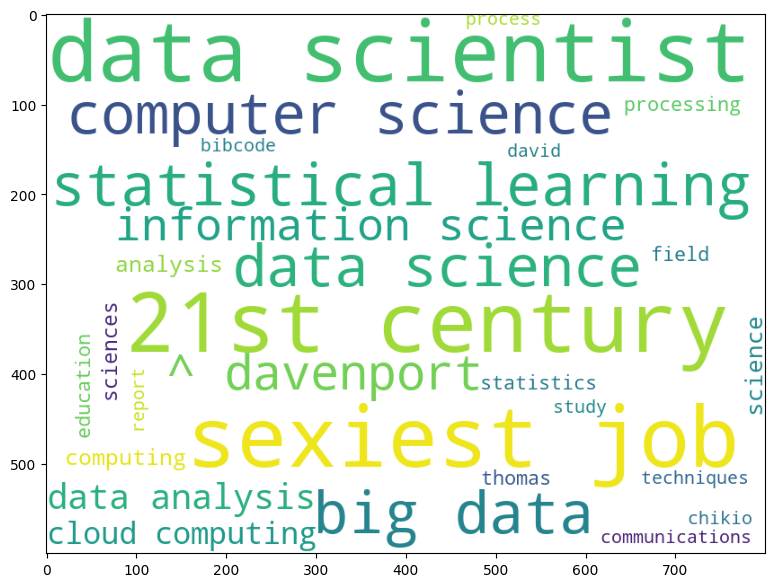

In [21]:
from wordcloud import WordCloud

wc = WordCloud(background_color='white', width=800, height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({k:v for k,v in res}))

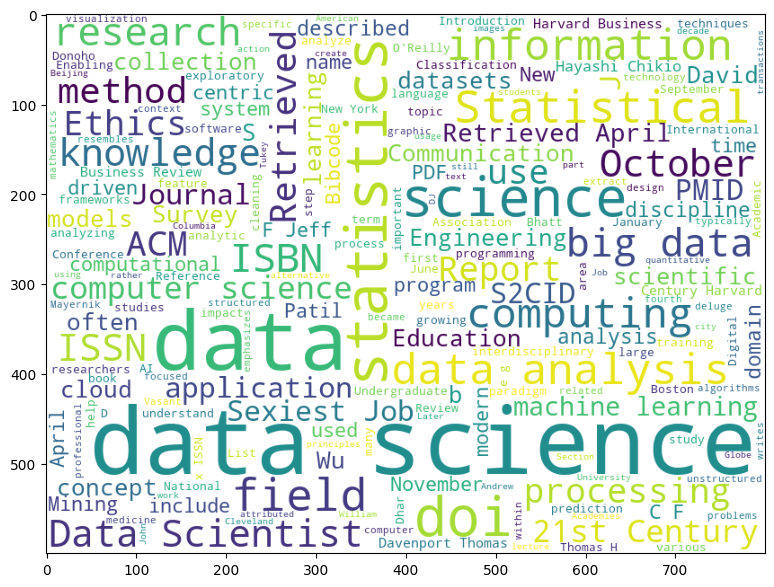

In [22]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(teks))

In [24]:
wc.generate(teks).to_file('images/ds_wordcloud.png')